### Wczytanie danych (i bibliotek)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# 1. Eksploracyjna analiza danych

### Wczytanie i zrozumienie danych

In [23]:
df = pd.read_csv('../data/Hotel Reservations.csv')
print(f"Liczba wierszy: {df.shape[0]}, liczba kolumn: {df.shape[1]}")
df.head()

Liczba wierszy: 36275, liczba kolumn: 19


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


### Typy danych i zmiennych

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [25]:
print("Zmienne numeryczne")
df.describe()

Zmienne numeryczne


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [26]:
print("Zmienne opisowe")
df.describe(include='object')

Zmienne opisowe


,Booking_ID,type_of_meal_plan,room_type_reserved,market_segment_type,booking_status
count,36275,36275,36275,36275,36275
unique,36275,4,7,5,2
top,INN00001,Meal Plan 1,Room_Type 1,Online,Not_Canceled
freq,1,27835,28130,23214,24390


In [27]:
df.market_segment_type.unique()

array(['Offline', 'Online', 'Corporate', 'Aviation', 'Complementary'],
      dtype=object)

### Sprawdzenie brakujących danych

In [28]:
print("Liczba brakujących wartości")
df.isnull().sum()

Liczba brakujących wartości


Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [29]:
print("Liczba duplikatów")
df.duplicated().sum()

Liczba duplikatów


np.int64(0)

In [30]:
df['booking_status'].value_counts(normalize=True) # Można tym sprawdzić sobie stosunek cancelled/not cancelled

booking_status
Not_Canceled    0.672364
Canceled        0.327636
Name: proportion, dtype: float64

### Hipotezy

Analizująć kolejne kolumny z ramki danych możemy postawić następujące hipotezy:
- im wcześniej robiono rezerwację, tym większa szansa anulacji (lead_time)
- powracający goście mogą rzadziej anulować rezerwacje (repeated_guest)
- segmenty kanałów sprzedaży mogą różnie wpływać na szansę anulacji, np.rezerwacje firmowe mogą być rzadziej odwoływane (market_segment_type)


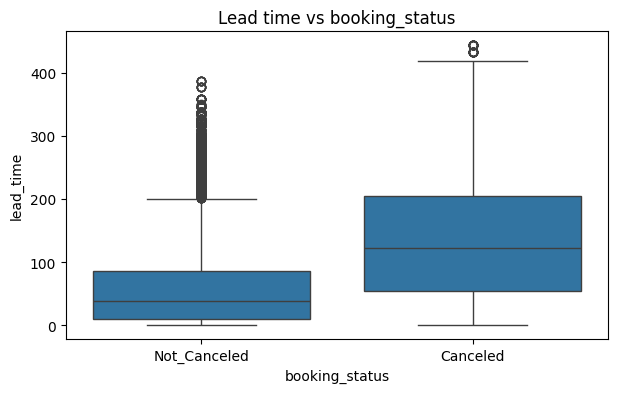

In [31]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='booking_status', y='lead_time')
plt.title('Lead time vs booking_status')
plt.show()

Im wcześniej robiono rezerwację, tym większa szansa na odwołanie.

In [32]:
pd.crosstab(df['repeated_guest'], df['booking_status'], normalize='index') * 100

booking_status,Canceled,Not_Canceled
repeated_guest,,
0,33.580422,66.419578
1,1.720430,98.279570


Powracający goście mają o wiele rzadziej odwołują rezerwacje.

booking_status,Canceled,Not_Canceled
market_segment_type,,
Aviation,29.60,70.40
Complementary,0.00,100.00
Corporate,10.91,89.09
Offline,29.95,70.05
Online,36.51,63.49


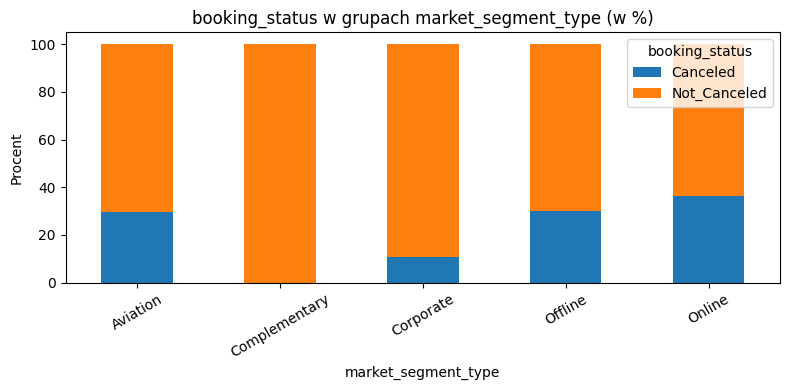

In [33]:
mseg = pd.crosstab(df['market_segment_type'], df['booking_status'], normalize='index') * 100
mseg = mseg.round(2)
display(mseg)
mseg.plot(kind='bar', stacked=True, figsize=(8,4))
plt.title('booking_status w grupach market_segment_type (w %)')
plt.xlabel('market_segment_type')
plt.ylabel('Procent')
plt.legend(title='booking_status')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Rezerwacje robione online są najbardziej podatne na anulowanie. Najmniej odwołanych rezerwacji było w segmencie "Compemantary".

### Analiza rozkładów i zależności

In [34]:
target_col = 'booking_status'
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove(target_col)
print('Numeryczne:', num_cols)
print('Kategoryczne:', cat_cols)

Numeryczne: ['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests']
Kategoryczne: ['Booking_ID', 'type_of_meal_plan', 'room_type_reserved', 'market_segment_type']


In [35]:
df.no_of_previous_bookings_not_canceled

0        0
1        0
2        0
3        0
4        0
        ..
36270    0
36271    0
36272    0
36273    0
36274    0
Name: no_of_previous_bookings_not_canceled, Length: 36275, dtype: int64

### Najważniejsze zmienne numeryczne

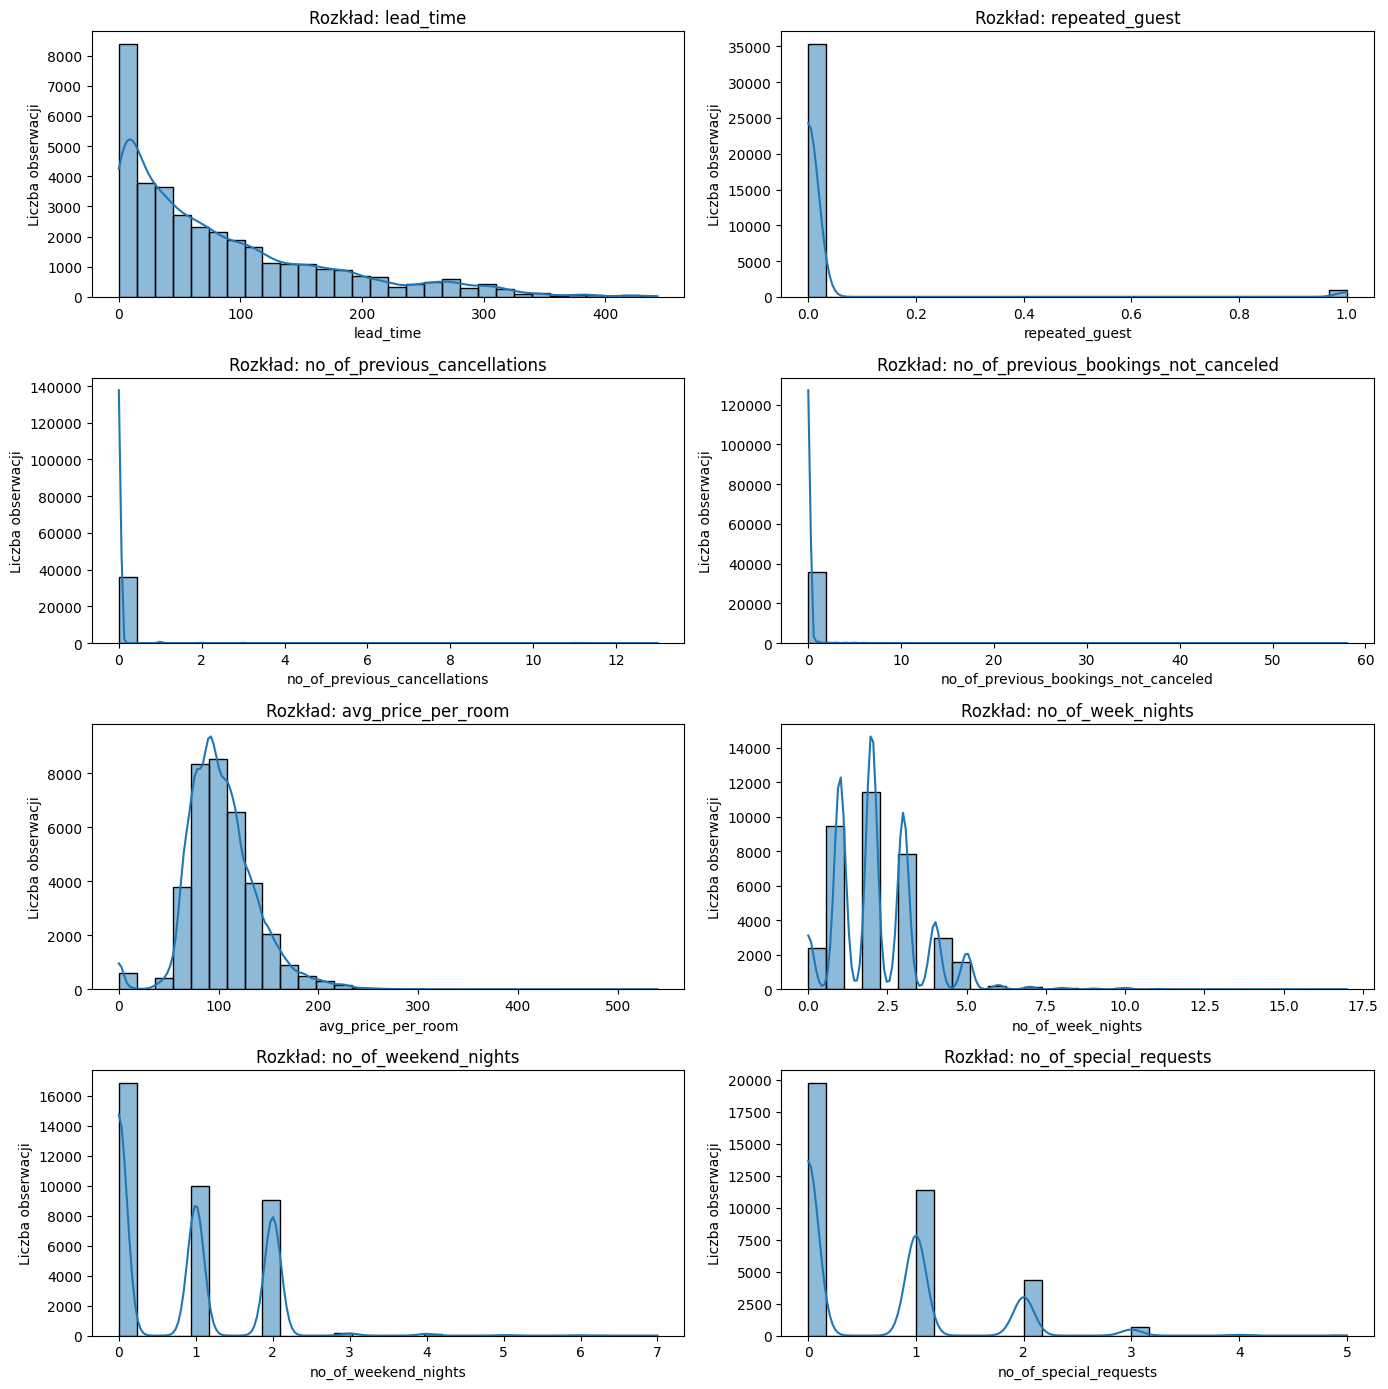

In [36]:
important_num = [
    'lead_time',
    'repeated_guest',
    'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled',
    'avg_price_per_room',
    'no_of_week_nights',
    'no_of_weekend_nights',
    'no_of_special_requests'
]

fig, ax = plt.subplots(4, 2, figsize=(14, 14))

for i, col in enumerate(important_num):
    sns.histplot(df[col], bins=30, kde=True, ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f'Rozkład: {col}')
    ax[i//2, i%2].set_xlabel(col)
    ax[i//2, i%2].set_ylabel('Liczba obserwacji')

plt.tight_layout()
plt.show()

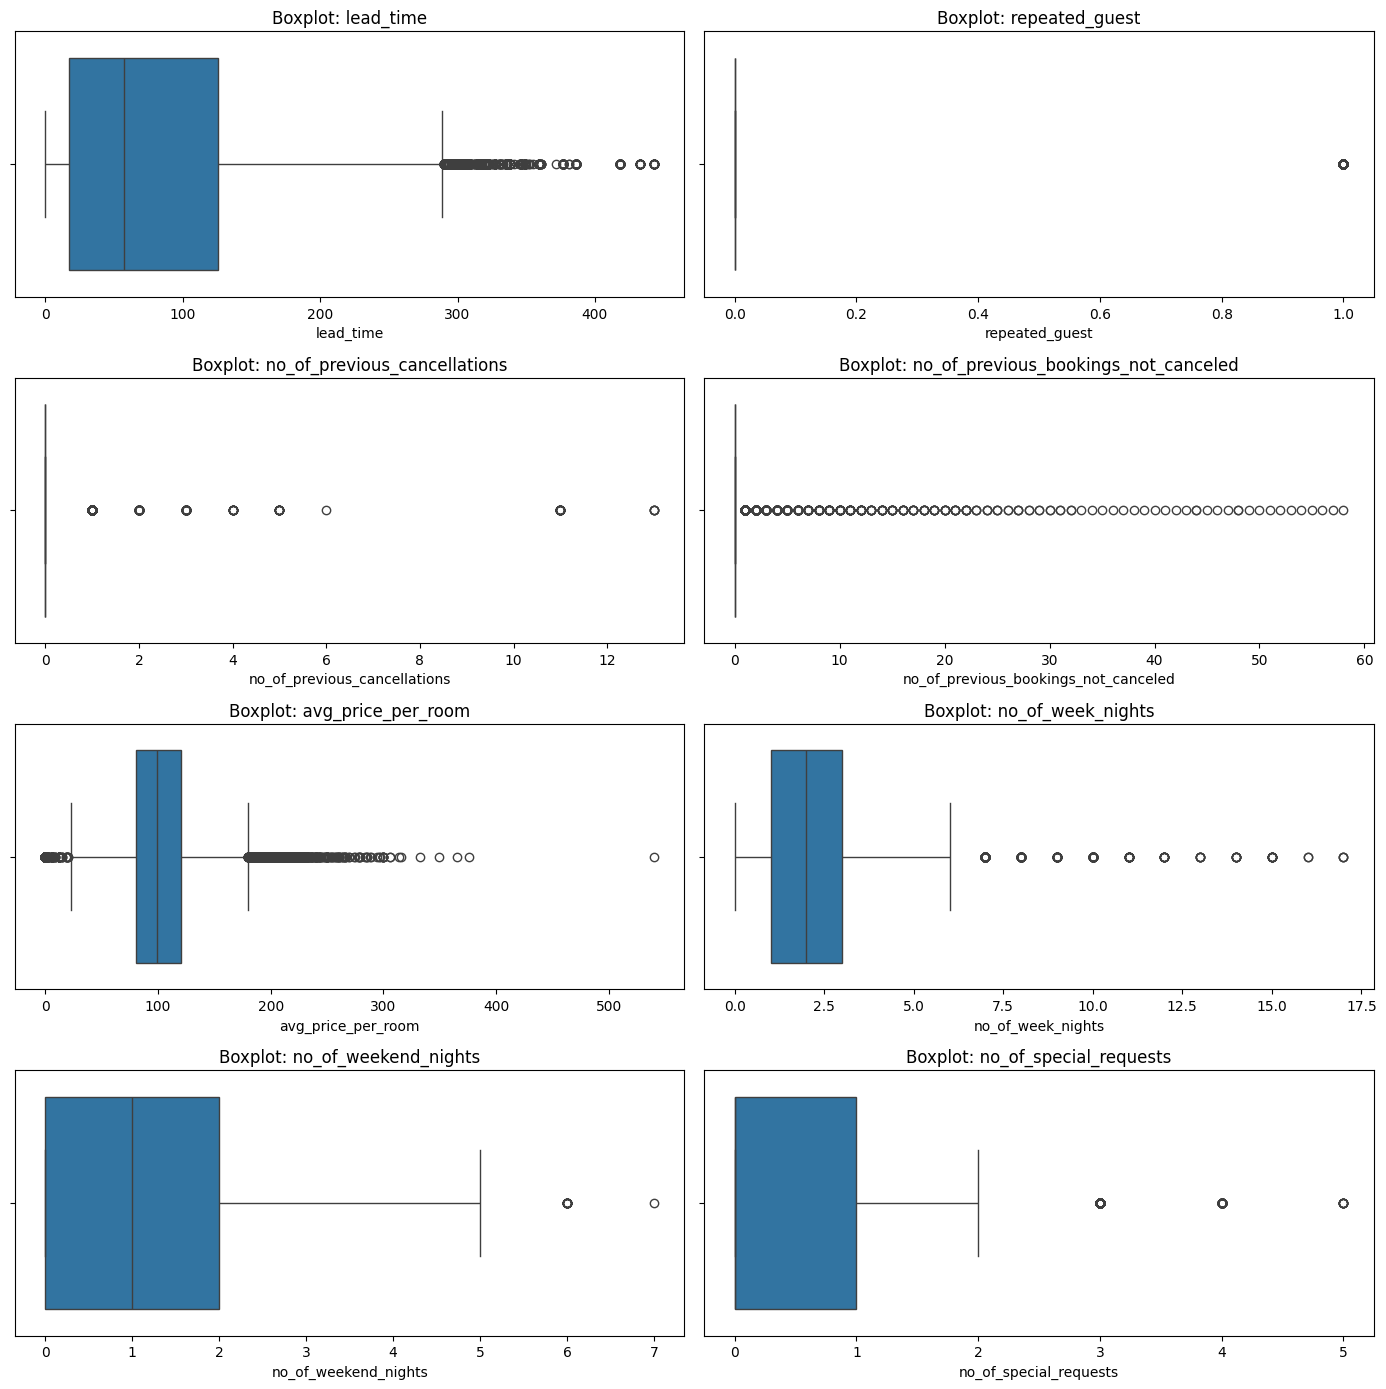

In [37]:
fig, ax = plt.subplots(4, 2, figsize=(14, 14))

for i, col in enumerate(important_num):
    sns.boxplot(x=df[col], ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f'Boxplot: {col}')
    ax[i//2, i%2].set_xlabel(col)

plt.tight_layout()
plt.show()

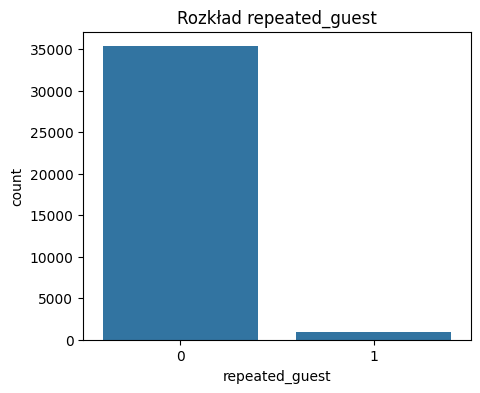

In [38]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='repeated_guest')
plt.title("Rozkład repeated_guest")
plt.show() 
# jest to zmienna binarna, więc lepiej ją widać na wykresie słupkowym

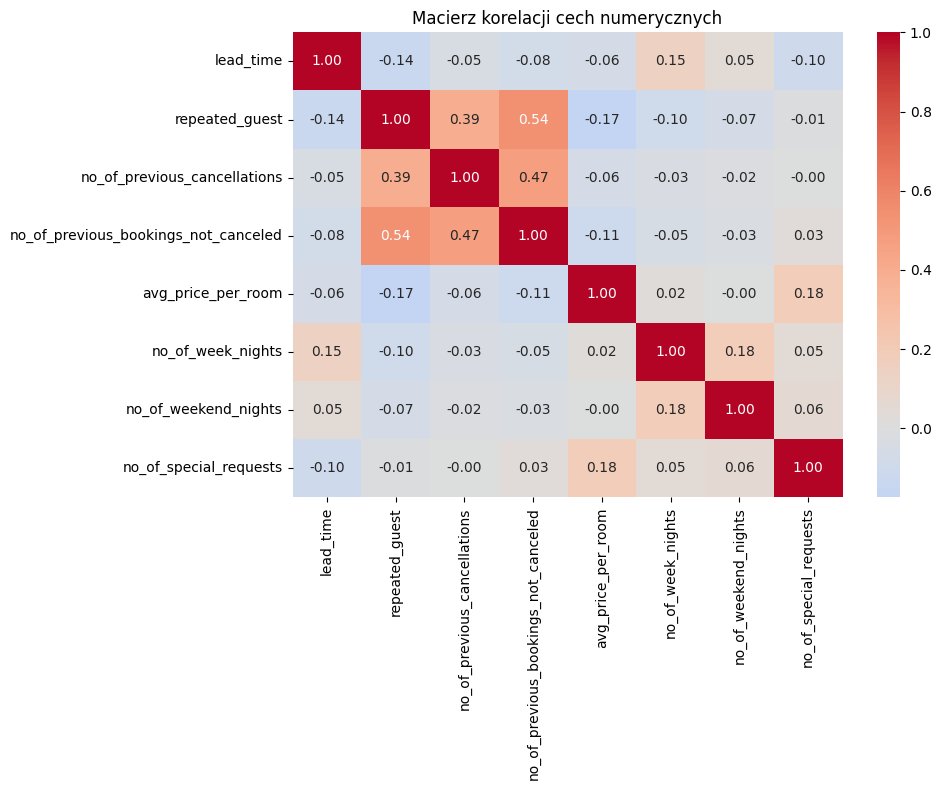

In [39]:
corr = df[important_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Macierz korelacji cech numerycznych')
plt.tight_layout()
plt.show()

Widać, że najbardziej skorelowane ze sobą cechy to:
- repeated_guest i no_of_previous_bookings_not_canceled
- repeated_guest i no_of_previous_cancellations
- no_of_previous_cancellations i no_of_previous_bookings_not_canceled

Jest to zgodne z intuicją - poracający goście częściej posiadają historię wcześniejszych rezerwacji. Pozostałe korelacje nie wskazują na istotane zależności liniowe.


### Najważniejsze zmienne kategoryczne

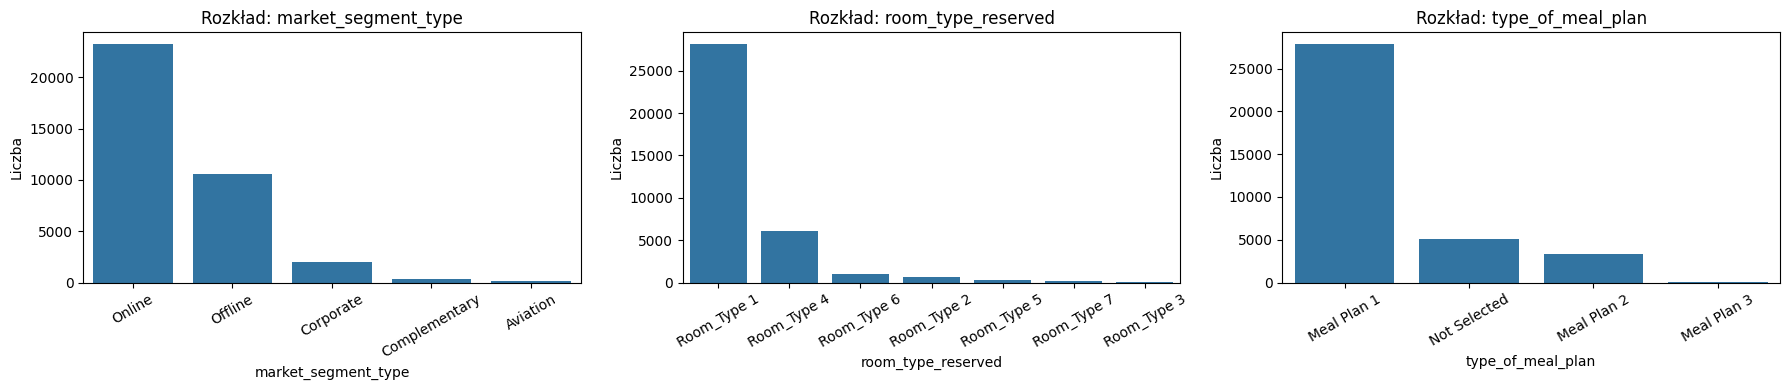

In [40]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

important_cat = [
    "market_segment_type",
    "room_type_reserved",
    "type_of_meal_plan"
]

for i, col in enumerate(important_cat):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax[i])
    ax[i].set_title(f"Rozkład: {col}")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Liczba")
    ax[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Badanie niuansu w postaci outlierów ceny pokoju wynoszącej 0

Darmowych pokoi: 545 (1.50% całego zbioru)


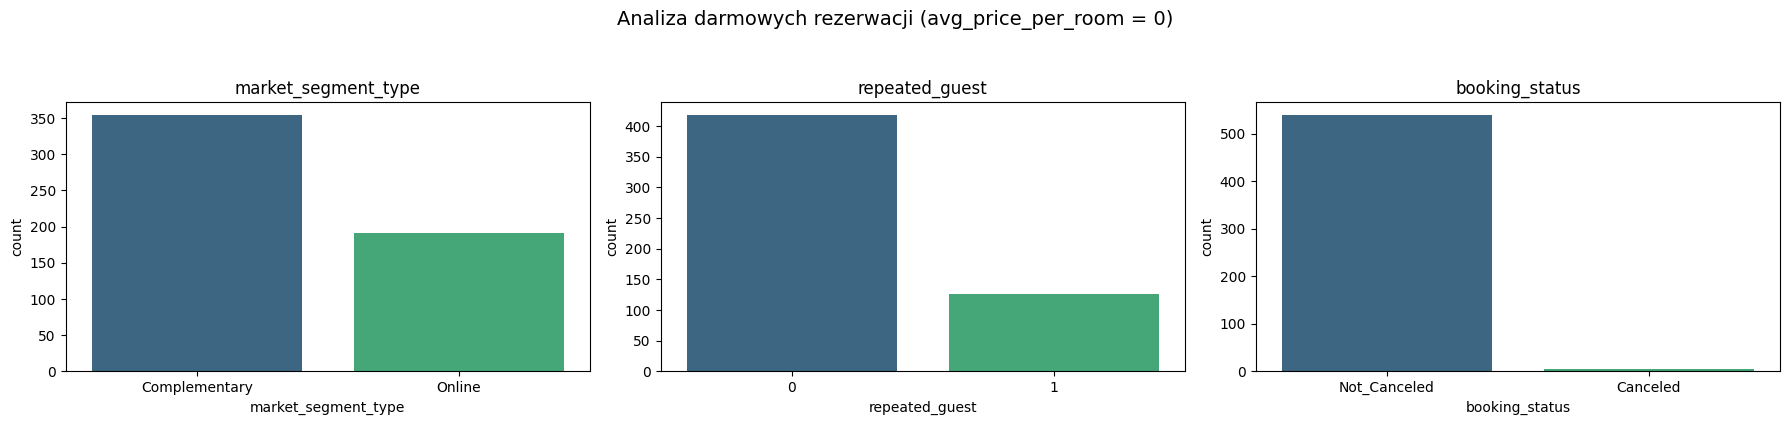

In [41]:
free_rooms = df[df['avg_price_per_room'] == 0]

print(f"Darmowych pokoi: {len(free_rooms)} ({len(free_rooms)/len(df)*100:.2f}% całego zbioru)")

cols_to_plot = ['market_segment_type', 'repeated_guest', 'booking_status']

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Analiza darmowych rezerwacji (avg_price_per_room = 0)", fontsize=14, y=1.05)

for i, col in enumerate(cols_to_plot):
    sns.countplot(data=free_rooms, x=col, ax=ax[i], order=free_rooms[col].value_counts().index, palette='viridis')
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

In [42]:
free_rooms = df[df['avg_price_per_room'] == 0]

print(free_rooms['repeated_guest'].value_counts())

print(free_rooms['booking_status'].value_counts())

counts = free_rooms['booking_status'].value_counts()
cancelled = counts.get('Canceled', 0)
not_cancelled = counts.get('Not_Canceled', 0)
percentage = cancelled / (cancelled + not_cancelled) * 100

print(f"\nProcent anulowanych: {percentage:.2f}%")

repeated_guest
0    418
1    127
Name: count, dtype: int64
booking_status
Not_Canceled    539
Canceled          6
Name: count, dtype: int64

Procent anulowanych: 1.10%


Główną obserwacją jest to, że pokoje te mają marginalny odsetek anulacji, bardzo rzadko kiedy pobyt w takich pokojach nie odbywa się.

### Wnioski

Na podstawie powyższych wykresów, możemy zauważyć, że:
- większość klientów rezerwuje do ok. 3 miesięcy z wyprzedzeniem, ale część rezerwuje bardzo wcześnie, nawet ponad rok wcześniej (dużo wartości odstających)
- więcej wartości odstających przy braku anulowania rezerwacji, niż przy anulowaniu rezerwacji, czyli większość klientów nie ma historii anulacji
- cena pokojów ma bardzo dużo outlierów
- większość pobytów jest krótkich, zwłaszcza weekendowych
- większość gości nie zgłasza specjalnych próśb
- najwięcej rezerwacji było robionych online
- najczęściej był rezerwowany pokój nr 1
- najczęściej był wybierany posiłek nr 1
- w przypadku darmowych pokojów, częstotliwość anulowania rezerwacji wynosiła ok 1%